5 DATA PERTAMA
    Brand  Processor_Speed  RAM_Size  Storage_Capacity  Screen_Size    Weight  \
0    Asus         3.830296        16               512    11.185147  2.641094   
1    Acer         2.912833         4              1000    11.311372  3.260012   
2  Lenovo         3.241627         4               256    11.853023  2.029061   
3    Acer         3.806248        16               512    12.280360  4.573865   
4    Acer         3.268097        32              1000    14.990877  4.193472   

          Price  
0  17395.093065  
1  31607.605919  
2   9291.023542  
3  17436.728334  
4  32917.990718  

INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             1000 non-null   object 
 1   Processor_Speed   1000 non-null   float64
 2   RAM_Size          1000 non-null   int64  
 3   Storage_Capacity  1000 non-null

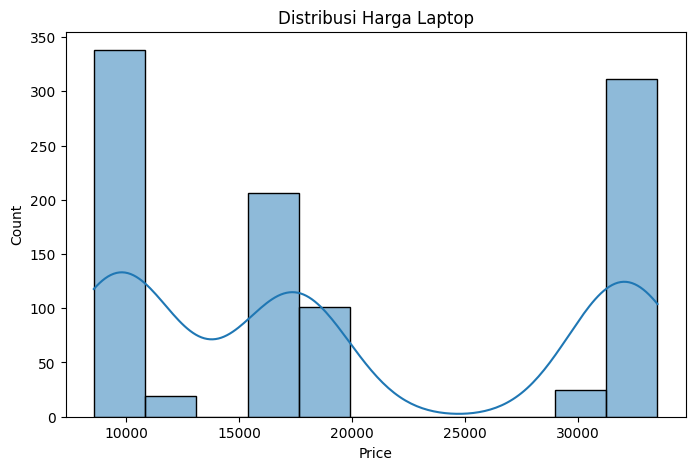

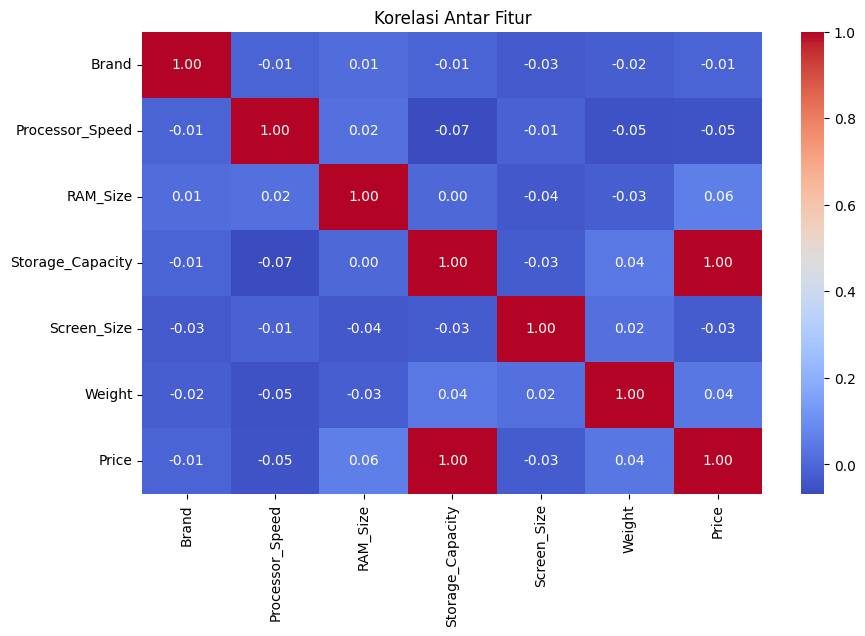


Jumlah Data Train : 800
Jumlah Data Test  : 200

Melakukan Tuning SVR...

Best Parameter SVR
{'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}

Melakukan Tuning KNN...

Best Parameter KNN
{'n_neighbors': 3, 'weights': 'distance'}

===== SVR =====
MAE  : 4459.85
RMSE : 5457.80
R²   : 0.6719

===== KNN =====
MAE  : 796.44
RMSE : 1568.98
R²   : 0.9729

PERBANDINGAN MODEL
  Model          MAE         RMSE        R2
0   SVR  4459.845100  5457.795637  0.671931
1   KNN   796.435958  1568.976503  0.972888


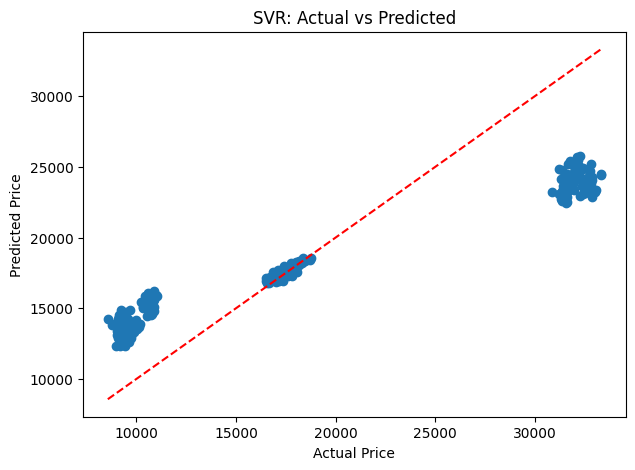

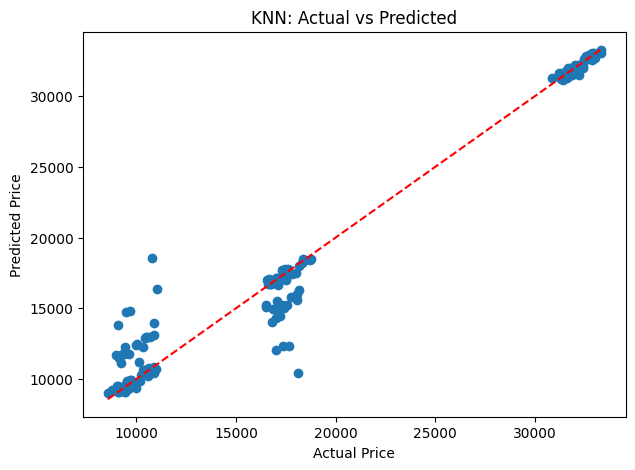

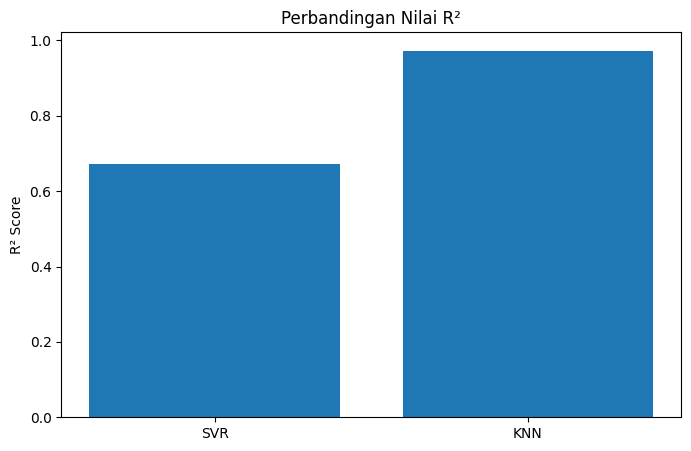


Menghitung Feature Importance...

Feature Importance
            Feature  Importance
3  Storage_Capacity    0.881548
5            Weight    0.005027
4       Screen_Size    0.003452
2          RAM_Size    0.003419
0             Brand    0.001102
1   Processor_Speed    0.000937


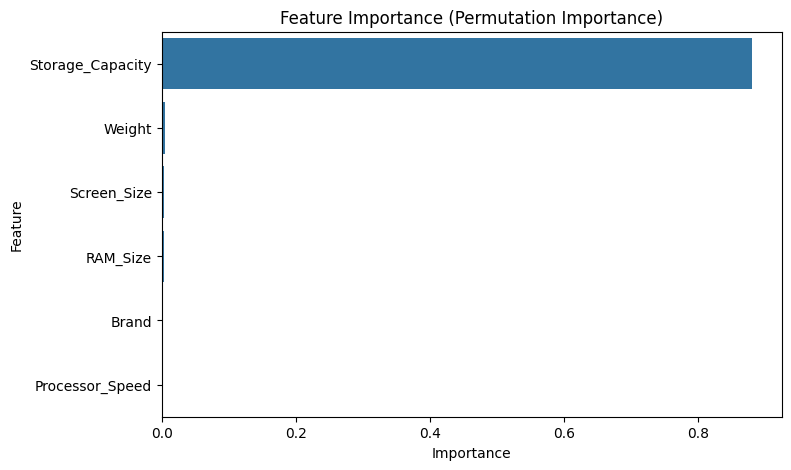


Program selesai dijalankan.


In [ ]:
# =====================================================
# PREDIKSI HARGA LAPTOP MENGGUNAKAN SVR DAN KNN
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.inspection import permutation_importance

# =====================================================
# 1. LOAD DATASET
# =====================================================

df = pd.read_csv("Laptop_price.csv")

print("="*50)
print("5 DATA PERTAMA")
print(df.head())

print("\nINFO DATASET")
print(df.info())

print("\nSTATISTIK DESKRIPTIF")
print(df.describe())

# =====================================================
# 2. EDA
# =====================================================

print("\nJumlah Missing Value:")
print(df.isnull().sum())

# Distribusi Harga
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], kde=True)
plt.title("Distribusi Harga Laptop")
plt.show()

# =====================================================
# 3. ENCODING BRAND
# =====================================================

le = LabelEncoder()

df["Brand"] = le.fit_transform(df["Brand"])

# =====================================================
# 4. KORELASI FITUR
# =====================================================

plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Korelasi Antar Fitur")
plt.show()

# =====================================================
# 5. FEATURE DAN TARGET
# =====================================================

X = df.drop("Price", axis=1)
y = df["Price"]

# =====================================================
# 6. SPLIT DATA
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nJumlah Data Train :", len(X_train))
print("Jumlah Data Test  :", len(X_test))

# =====================================================
# 7. STANDARDISASI
# =====================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =====================================================
# 8. HYPERPARAMETER TUNING SVR
# =====================================================

print("\nMelakukan Tuning SVR...")

svr_param = {
    'kernel': ['rbf'],
    'C': [1, 10, 100],
    'gamma': ['scale', 0.1, 0.01]
}

grid_svr = GridSearchCV(
    SVR(),
    svr_param,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_svr.fit(X_train_scaled, y_train)

best_svr = grid_svr.best_estimator_

print("\nBest Parameter SVR")
print(grid_svr.best_params_)

# =====================================================
# 9. HYPERPARAMETER TUNING KNN
# =====================================================

print("\nMelakukan Tuning KNN...")

knn_param = {
    'n_neighbors': [3,5,7,9,11],
    'weights': ['uniform','distance']
}

grid_knn = GridSearchCV(
    KNeighborsRegressor(),
    knn_param,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_knn.fit(X_train_scaled, y_train)

best_knn = grid_knn.best_estimator_

print("\nBest Parameter KNN")
print(grid_knn.best_params_)

# =====================================================
# 10. TRAINING MODEL
# =====================================================

best_svr.fit(X_train_scaled, y_train)
best_knn.fit(X_train_scaled, y_train)

# =====================================================
# 11. PREDIKSI
# =====================================================

pred_svr = best_svr.predict(X_test_scaled)
pred_knn = best_knn.predict(X_test_scaled)

# =====================================================
# 12. EVALUASI
# =====================================================

def evaluate(y_true, y_pred, model_name):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    print(f"\n===== {model_name} =====")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")

    return mae, rmse, r2

svr_mae, svr_rmse, svr_r2 = evaluate(
    y_test,
    pred_svr,
    "SVR"
)

knn_mae, knn_rmse, knn_r2 = evaluate(
    y_test,
    pred_knn,
    "KNN"
)

# =====================================================
# 13. TABEL PERBANDINGAN
# =====================================================

comparison = pd.DataFrame({
    'Model':['SVR','KNN'],
    'MAE':[svr_mae,knn_mae],
    'RMSE':[svr_rmse,knn_rmse],
    'R2':[svr_r2,knn_r2]
})

print("\nPERBANDINGAN MODEL")
print(comparison)

# =====================================================
# 14. VISUALISASI PREDIKSI SVR
# =====================================================

plt.figure(figsize=(7,5))

plt.scatter(y_test, pred_svr)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("SVR: Actual vs Predicted")

plt.show()

# =====================================================
# 15. VISUALISASI PREDIKSI KNN
# =====================================================

plt.figure(figsize=(7,5))

plt.scatter(y_test, pred_knn)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("KNN: Actual vs Predicted")

plt.show()

# =====================================================
# 16. GRAFIK PERBANDINGAN MODEL
# =====================================================

plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["R2"]
)

plt.title("Perbandingan Nilai R²")
plt.ylabel("R² Score")

plt.show()

# =====================================================
# 17. FEATURE IMPORTANCE
# =====================================================

print("\nMenghitung Feature Importance...")

perm = permutation_importance(
    best_svr,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=42
)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm.importances_mean
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance")
print(importance)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance (Permutation Importance)")
plt.show()

# =====================================================
# SELESAI
# =====================================================

print("\nProgram selesai dijalankan.")